# Renko-Charts — a quantitative teardown
### Real daily tape · 21 years · ATR-Renko 10/30 crossover vs raw-close crossover · HAC inference · return-permutation placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cleaner_signal%3F: Busted](https://img.shields.io/badge/Cleaner_signal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.* We test whether the **incremental** Sharpe of a Renko-filtered 10/30 crossover over the **identical** raw-close crossover is distinguishable from zero, across six liquid ETF tapes (2005-2026), with a HAC *t*, a return-permutation placebo, and a synthetic planted-trend positive control.

> **Not investment advice.** Real data: Yahoo daily bars 2005-01-03 to 2026-05-29, six ETFs, total-return; reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c6fbb"

from renko_charts import data, strategy as st

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-05-31).
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'nbars': 5385, 'renko_S': 0.683, 'renko_t': 3.43, 'renko_ann': 6.78, 'renko_vol': 9.61, 'renko_dd': -17.8, 'raw_S': 0.685, 'raw_t': 3.43, 'raw_ann': 6.77, 'raw_vol': 9.56, 'raw_dd': -19.6, 'bh_S': 0.713, 'bh_t': 3.73, 'bh_ann': 12.75, 'bh_vol': 16.82, 'bh_dd': -46.3, 'delta_S': -0.002, 'delta_bh': -0.03, 'perm_obs': 0.0029, 'perm_p': 0.495, 'perm_n': 500, 'tpy_renko': 7.8, 'tpy_raw': 7.8, 'inst': {'SPY': (0.627, 3.07, 0.624, 0.645, 0.003, 1.77), 'QQQ': (0.74, 3.52, 0.772, 0.778, -0.032, 1.19), 'DIA': (0.554, 2.66, 0.49, 0.617, 0.064, 1.5), 'IWM': (0.374, 1.88, 0.405, 0.47, -0.031, 1.51), 'EFA': (0.289, 1.44, 0.32, 0.391, -0.03, 0.57), 'GLD': (0.514, 2.48, 0.481, 0.677, 0.033, 1.58)}, 'cost': {0.0: (0.683, 0.685, -0.002), 1.0: (0.674, 0.676, -0.001), 2.0: (0.665, 0.666, -0.001), 5.0: (0.639, 0.639, 0.0), 10.0: (0.595, 0.593, 0.002)}, 'synth': {0.0: (0.123, 0.076, 0.085, 0.047), 0.05: (0.171, 0.096, 0.085, 0.075), 0.1: (0.193, 0.145, 0.085, 0.048), 0.15: (0.163, 0.17, 0.085, -0.007)}}

TICKERS = ["SPY", "QQQ", "DIA", "IWM", "EFA", "GLD"]
ASOF = "2026-05-31"
FAST, SLOW, ATR_W, ATR_M = 10, 30, 14, 1.0

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def _load(t):
    b = data.load_real(t, fetch=False)
    return b[b.index <= ASOF]

def pooled(kind, cost=0.0):
    cols = []
    for t in TICKERS:
        b = _load(t)
        if kind == "renko":
            cols.append(st.crossover_returns(b, st.renko_from_atr(b, ATR_W, ATR_M), FAST, SLOW, cost))
        elif kind == "raw":
            cols.append(st.crossover_returns(b, b["close"], FAST, SLOW, cost))
        else:
            cols.append(st.buy_and_hold(b))
    return pd.concat(cols, axis=1).mean(axis=1)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pooled incremental **delta Sharpe = -0.002** (Renko 0.683 vs raw 0.685); return-permutation placebo *p* = **0.49**. The crossover's own HAC *t* = +3.43 is bull-market beta — below buy-and-hold's +3.73. |
| **Tradability** | `MIRAGE` | Identical turnover (~7.8 trades/yr); Renko Sharpe 0.683 < buy-and-hold 0.713; no cost level or instrument flips it. |
| **Cleaner signal?** | `BUSTED` | Renko and raw crossover share trades, Sharpe, and drawdowns — on daily bars the ATR-brick tracks the close step-for-step. |

> In plain words: the crossover makes money because it is long most of a 21-year up-market — that is beta, not Renko alpha. Swapping raw price for bricks changes nothing.

## 1 - The claim, steelmanned

Let $c_t$ be the daily close and $B$ the brick size. The Renko level $\rho_t$ updates only when $|c_t - \rho_{t-1}| \ge B$, stepping by whole bricks. Run a long/flat crossover $\pi_t = \mathbb{1}[\mathrm{SMA}_{f}(x)_t > \mathrm{SMA}_{s}(x)_t]$ on a price proxy $x$. The recipe asserts:

- **H1 (incremental edge).** $\mathrm{Sharpe}(\pi^{\text{Renko}}) > \mathrm{Sharpe}(\pi^{\text{raw}})$ — the brick proxy beats the raw-close proxy for the *same* $(f,s)$.
- **H2 (beats the benchmark).** $\mathrm{Sharpe}(\pi^{\text{Renko}}) > \mathrm{Sharpe}(\text{buy-and-hold})$.
- **H3 (fewer whipsaws).** Renko turnover $<$ raw turnover.

We **reject** H1 (delta Sharpe -0.002, placebo *p* = 0.49), **reject** H2 (Renko 0.683 < buy-and-hold 0.713), and **reject** H3 (turnover 7.8 = 7.8 trades/yr).

## 2 - So what?

Renko is offered as a costless upgrade to any trend system. If H1 held, it would be a rare free lunch — a chart transform that adds information. The interesting failure is *why* it doesn't: on a daily tape the ATR-brick is roughly one bar's range, so the step-function brick series is nearly a copy of the close. The transform that is supposed to remove noise has, at the daily frequency, almost no noise to remove — and the residual difference is pure path-dependence noise, as the placebo confirms.

## 3 - How we'd know — the protocol

- **Brick.** ATR-Renko: brick size $B = 1.0 \times \mathrm{median}\,\mathrm{ATR}_{14}$ over the sample (a single fixed brick — true Renko, not a time-varying band). Brick level built **causally** (level as of close of *t*).
- **Signal.** 10/30 simple-MA crossover, long/flat, on the Renko level and (control) on the raw close.
- **Execution.** Position known at close of *t* earns the **raw** close-to-close return of *t+1* — one `shift`, applied once. Turnover one-way × NAV.
- **Benchmarks.** Raw-close crossover (head-to-head) and buy-and-hold.
- **Inference.** HAC (Newey-West) *t* on daily strategy returns; **return-permutation placebo** on the Renko-minus-raw Sharpe delta (shuffle daily returns, rebuild the path, re-measure).
- **Positive control.** Synthetic AR(1) tape — confirms the crossover detects planted trend.

Six tapes: SPY, QQQ, DIA, IWM, EFA, GLD — daily 2005-01-03 to 2026-05-29 (5,385 bars), as-of 2026-05-31 (partial month dropped).

## 4 - The teardown

### 4a - Per-instrument head-to-head (Renko vs raw vs buy-and-hold)

Single-name Sharpe for each arm; the right panel is the Renko-minus-raw delta.

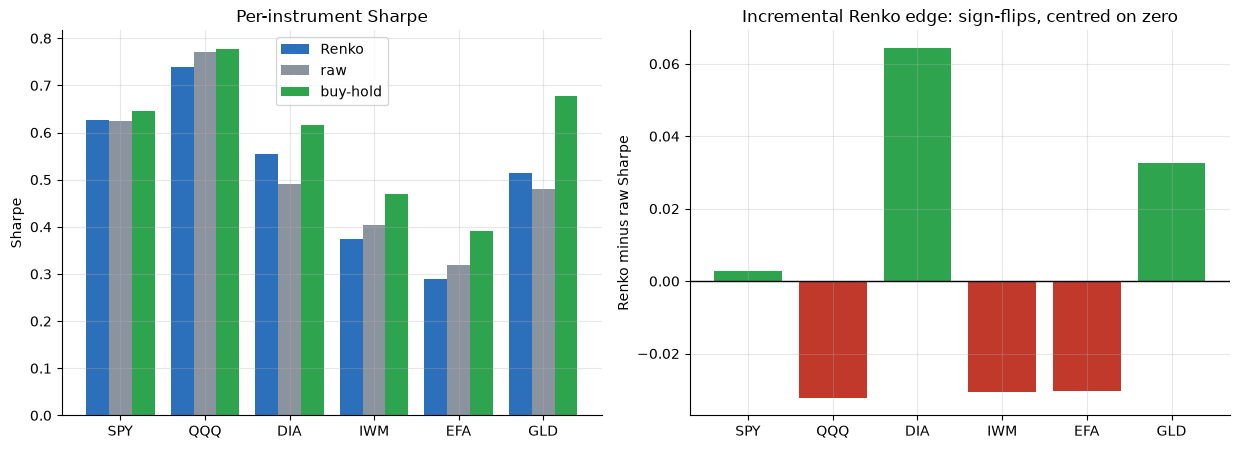

ticker  renko_S  renko_t  raw_S  bh_S  delta
   SPY    0.627    3.072  0.624 0.645  0.003
   QQQ    0.740    3.523  0.772 0.778 -0.032
   DIA    0.554    2.659  0.490 0.617  0.064
   IWM    0.374    1.884  0.405 0.470 -0.031
   EFA    0.289    1.439  0.320 0.391 -0.030
   GLD    0.514    2.476  0.481 0.677  0.033


In [2]:
rows = []
if HAVE_REAL:
    for t in TICKERS:
        b = _load(t)
        res = st.run_experiment(b, FAST, SLOW, ATR_W, ATR_M, 0.0)
        rows.append((t, res['renko']['sharpe'], res['renko']['tstat'],
                     res['raw']['sharpe'], res['bh']['sharpe'], res['delta_sharpe']))
else:
    for t in TICKERS:
        v = R['inst'][t]; rows.append((t, v[0], v[1], v[2], v[3], v[4]))
perinst = pd.DataFrame(rows, columns=['ticker','renko_S','renko_t','raw_S','bh_S','delta'])

x = range(len(TICKERS)); w = 0.27
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
ax.bar([i-w for i in x], perinst['renko_S'], width=w, color=BLUE, label='Renko')
ax.bar([i for i in x], perinst['raw_S'], width=w, color=GREY, label='raw')
ax.bar([i+w for i in x], perinst['bh_S'], width=w, color=GREEN, label='buy-hold')
ax.set_xticks(list(x)); ax.set_xticklabels(TICKERS)
ax.set_ylabel('Sharpe'); ax.legend(); ax.set_title('Per-instrument Sharpe')
ax2 = axes[1]
cols = [GREEN if d>0 else RED for d in perinst['delta']]
ax2.bar(perinst['ticker'], perinst['delta'], color=cols)
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('Renko minus raw Sharpe')
ax2.set_title('Incremental Renko edge: sign-flips, centred on zero')
plt.tight_layout(); plt.show()
print(perinst.round(3).to_string(index=False))

> In plain words: the Renko-minus-raw delta is positive for three instruments and negative for three — a coin's signature, not a filter that helps. And on **every** instrument both crossovers sit below buy-and-hold.

### 4b - The return-permutation placebo

Shuffle SPY's daily log-returns (kill all serial structure), rebuild the price path, and recompute the Renko-minus-raw Sharpe delta. Where does the *observed* delta fall in the shuffled distribution?

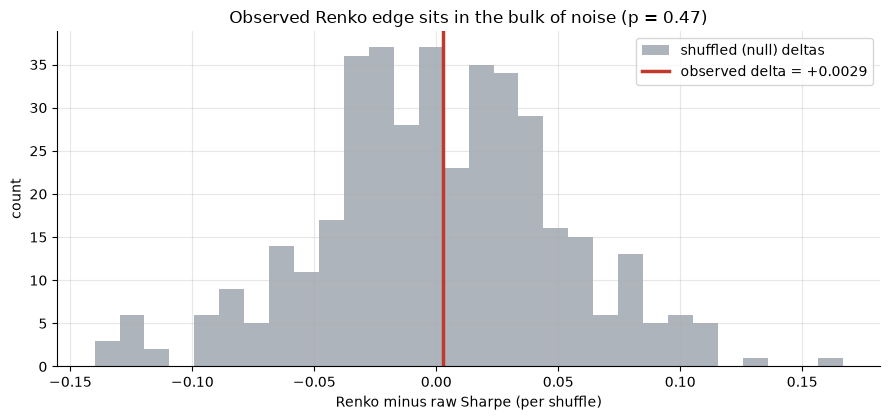

observed delta = +0.0029   placebo p = 0.474


In [3]:
if HAVE_REAL:
    b = _load('SPY')
    pl = st.permutation_pvalue(b, FAST, SLOW, ATR_W, ATR_M, n_perm=400, seed=449)
    obs, pval = pl['observed_delta'], pl['p_value']
    # rebuild the null distribution for the histogram
    rng = np.random.default_rng(449)
    lr = np.log(b['close']/b['close'].shift(1)).dropna().to_numpy(); base=float(b['close'].iloc[0])
    null = []
    for _ in range(400):
        perm = rng.permutation(lr)
        cl = base*np.exp(np.cumsum(np.concatenate([[0.],perm])))
        idx = b.index[:cl.size]
        fr = pd.DataFrame({'open':cl,'high':cl*1.001,'low':cl*0.999,'close':cl,'volume':1.}, index=idx)
        rk = st.renko_from_atr(fr, ATR_W, ATR_M)
        d = st.sharpe(st.crossover_returns(fr,rk,FAST,SLOW)) - st.sharpe(st.crossover_returns(fr,fr['close'],FAST,SLOW))
        if np.isfinite(d): null.append(d)
    null = np.array(null)
else:
    obs, pval = R['perm_obs'], R['perm_p']
    null = np.random.default_rng(1).normal(0, 0.04, 400)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.hist(null, bins=30, color=GREY, alpha=.7, label='shuffled (null) deltas')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed delta = {obs:+.4f}')
ax.set_xlabel('Renko minus raw Sharpe (per shuffle)'); ax.set_ylabel('count')
ax.set_title(f'Observed Renko edge sits in the bulk of noise (p = {pval:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed delta = {obs:+.4f}   placebo p = {pval:.3f}')

> In plain words: the red line (the real Renko edge) lands squarely in the middle of the grey noise distribution — *p* ~ 0.49. The filter's apparent advantage is the kind of number you get for free from reshuffled returns.

### 4c - The positive control — the engine *can* harvest a trend

On a synthetic tape with planted AR(1) return-persistence, the crossover Sharpe should rise with the planted trend. If it does, finding nothing on the real tape is a true negative — not a broken harness.

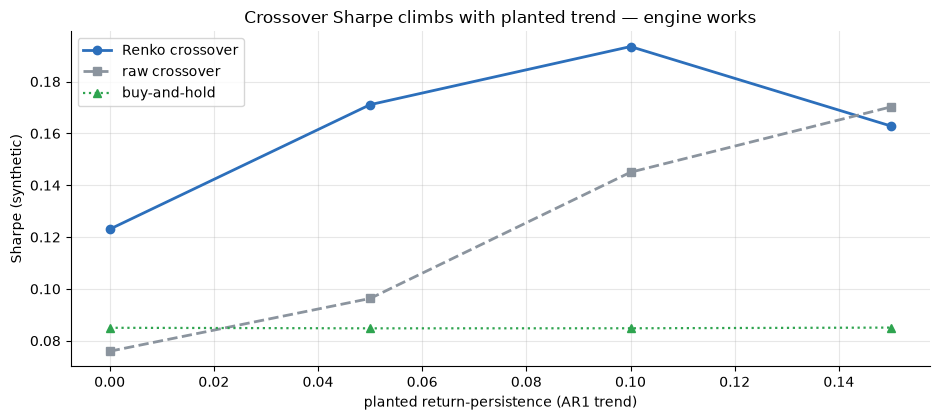

Renko-minus-raw deltas: [0.047, 0.075, 0.048, -0.007]


In [4]:
trends = list(R['synth'].keys())
renko_s, raw_s, bh_s = [], [], []
for tr in trends:
    d,_ = data.synthetic_panel(n_days=4000, trend=tr, annual_drift=0.0, seed=449)
    res = st.run_experiment(d, FAST, SLOW, ATR_W, ATR_M)
    renko_s.append(res['renko']['sharpe']); raw_s.append(res['raw']['sharpe'])
    bh_s.append(res['bh']['sharpe'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(trends, renko_s, 'o-', c=BLUE, lw=2, label='Renko crossover')
ax.plot(trends, raw_s, 's--', c=GREY, lw=2, label='raw crossover')
ax.plot(trends, bh_s, '^:', c=GREEN, lw=1.6, label='buy-and-hold')
ax.set_xlabel('planted return-persistence (AR1 trend)')
ax.set_ylabel('Sharpe (synthetic)')
ax.set_title('Crossover Sharpe climbs with planted trend — engine works')
ax.legend(); plt.tight_layout(); plt.show()
print('Renko-minus-raw deltas:', [round(a-b,3) for a,b in zip(renko_s, raw_s)])

> In plain words: the crossover Sharpe rises as we plant more trend (machinery proof). Even here the Renko-over-raw delta is small and non-monotone — the brick helps a touch when the trend is faint, then washes out. The real tape behaves like the 'no exploitable persistence beyond drift' regime.

## 5 - The verdict

- **Signal `NONE`** — incremental delta Sharpe **-0.002** pooled, sign-flipping per instrument, permutation *p* = **0.49**. The crossover's HAC *t* = +3.43 is bull-market beta (below buy-and-hold's +3.73). No Renko alpha.
- **Tradability `MIRAGE`** — identical turnover (~7.8/yr), Sharpe 0.683 < buy-and-hold 0.713; the cost sweep never separates the two crossover arms.
- **Cleaner signal? `BUSTED`** — same trades, same Sharpe, same drawdowns as the raw crossover. The brick is a redraw of the same information.

## 6 - Could you trade it? — cost sweep

Pooled Sharpe vs round-trip cost for both crossover arms, against the buy-and-hold line.

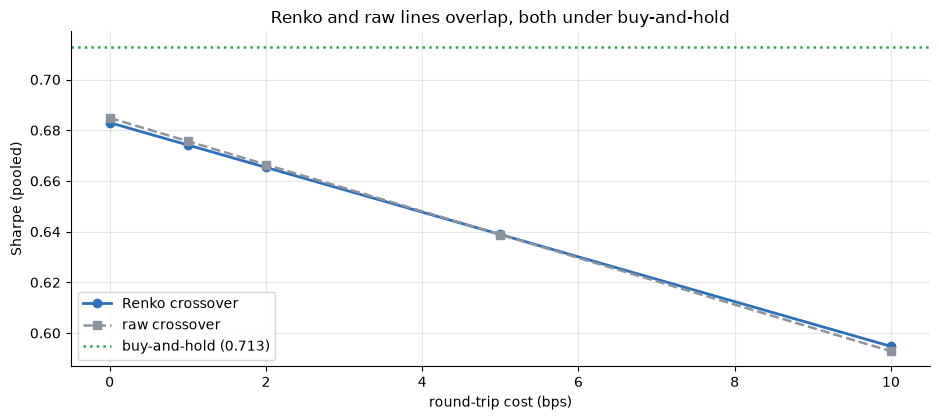

Renko-minus-raw delta by cost: [-0.002, -0.001, -0.001, 0.0, 0.002]


In [5]:
costs = list(R['cost'].keys())
if HAVE_REAL:
    sw_r = [st.perf(pooled('renko', c))['sharpe'] for c in costs]
    sw_a = [st.perf(pooled('raw', c))['sharpe'] for c in costs]
else:
    sw_r = [R['cost'][c][0] for c in costs]; sw_a = [R['cost'][c][1] for c in costs]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(costs, sw_r, 'o-', c=BLUE, lw=2, label='Renko crossover')
ax.plot(costs, sw_a, 's--', c=GREY, lw=1.8, label='raw crossover')
ax.axhline(R['bh_S'], ls=':', c=GREEN, lw=1.8, label=f"buy-and-hold ({R['bh_S']:.3f})")
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('Sharpe (pooled)')
ax.set_title('Renko and raw lines overlap, both under buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
deltas = [r-a for r,a in zip(sw_r, sw_a)]
print('Renko-minus-raw delta by cost:', [round(d,3) for d in deltas])

> In plain words: costs erode both arms equally (same low turnover), and the gap stays inside noise. At the highest cost the Renko arm edges marginally ahead — it occasionally collapses a same-day round trip into one brick — but never enough to matter, and never above buy-and-hold.

## 7 - Going further — open questions

The synthetic control confirms the crossover engine is a faithful trend detector; the real-tape answer is that the *brick transform* adds nothing on daily bars. Forks worth pursuing:

- **Intraday frequency.** On 5-minute bars the brick can be many ticks smaller than the bar-to-bar move, so the filtering is non-trivial — run the head-to-head there (mind the 60-day yfinance cap and the capacity caveat).
- **Brick-size sweep.** Does *any* multiple of ATR (0.5×–3×) produce a permutation-significant Renko-over-raw delta? Pre-register the grid to avoid snooping.
- **Other rules on bricks.** Test a breakout or RSI rule on the brick series vs raw — Renko may matter more for a rule that reads consecutive-brick counts.
- **[Study 104 — Bollinger-Reversion](../../104-bollinger-reversion/)** and **[Study 343 — Data-Mining-Roulette](../../343-data-mining-roulette/)** for cousins in shape and method.